# Cosa sta dicendo il campo C(x)?

Obiettivo: capire se i campi di influenza catturano informazione scacchistica reale,
e che tipo di informazione — controllo territoriale, tensione tattica, struttura posizionale?

Approccio: confrontiamo posizioni famose dove sappiamo già la risposta.

In [11]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as mpe
from matplotlib.patches import Rectangle
from chess_fields import compute_fields_from_fen, fen_to_board, PIECE_SYMBOLS, EMPTY
from visualize import plot_all_fields, plot_control_field, _draw_board_base

## Helper: visualizzazione con annotazione del campo C(x)

In [2]:
def plot_annotated(fen, title='', alpha=0.5, annotate_values=True):
    """
    Plot C(x) con i valori numerici su ogni casa.
    Verde = bianco controlla, Rosso = nero controlla.
    """
    fields = compute_fields_from_fen(fen, alpha=alpha)
    board  = fields['board']
    C      = fields['control']

    fig, ax = plt.subplots(figsize=(8, 8))
    LIGHT_SQ = '#F0D9B5'
    DARK_SQ  = '#B58863'

    vmax = max(abs(C).max(), 1e-6)

    for r in range(8):
        for c in range(8):
            # Board square color
            sq_color = LIGHT_SQ if (r+c)%2==0 else DARK_SQ
            ax.add_patch(Rectangle((c, 7-r), 1, 1, color=sq_color, zorder=0))

            # Influence overlay
            val = C[r, c]
            if val > 0.01:
                ax.add_patch(Rectangle((c, 7-r), 1, 1,
                    color='blue', alpha=min(val/vmax * 0.6, 0.6), zorder=1))
            elif val < -0.01:
                ax.add_patch(Rectangle((c, 7-r), 1, 1,
                    color='red', alpha=min(-val/vmax * 0.6, 0.6), zorder=1))

            # Numeric value
            if annotate_values:
                ax.text(c+0.5, 7-r+0.18, f'{val:+.2f}',
                    ha='center', va='bottom', fontsize=6.5,
                    color='white' if abs(val) > vmax*0.4 else 'black',
                    zorder=4)

            # Piece symbol
            piece = board[r, c]
            if piece != EMPTY:
                sym = PIECE_SYMBOLS[piece]
                txt_color = 'white' if piece < 0 else 'black'
                ax.text(c+0.5, 7-r+0.65, sym,
                    ha='center', va='center', fontsize=18, fontweight='bold',
                    color=txt_color, zorder=3,
                    path_effects=[mpe.withStroke(linewidth=2,
                        foreground='black' if piece < 0 else 'white')])

    # Labels
    for i in range(8):
        ax.text(i+0.5, -0.25, 'abcdefgh'[i], ha='center', fontsize=9)
        ax.text(-0.25, i+0.5, str(i+1), va='center', fontsize=9)

    ax.set_xlim(-0.4, 8.1)
    ax.set_ylim(-0.4, 8.1)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title or 'C(x) = Φ_white − Φ_black', fontsize=12)

    # Summary stats
    white_ctrl = (C > 0.05).sum()
    black_ctrl = (C < -0.05).sum()
    contested  = ((C >= -0.05) & (C <= 0.05)).sum()
    fig.text(0.12, 0.01,
        f'Blu (bianco): {white_ctrl} case   Rosso (nero): {black_ctrl} case   Contestate: {contested} case',
        fontsize=9)

    plt.tight_layout()
    return fig, C

print('Helper caricato.')

Helper caricato.


---
## Esperimento 1: Posizione iniziale
Atteso: campo quasi perfettamente simmetrico.

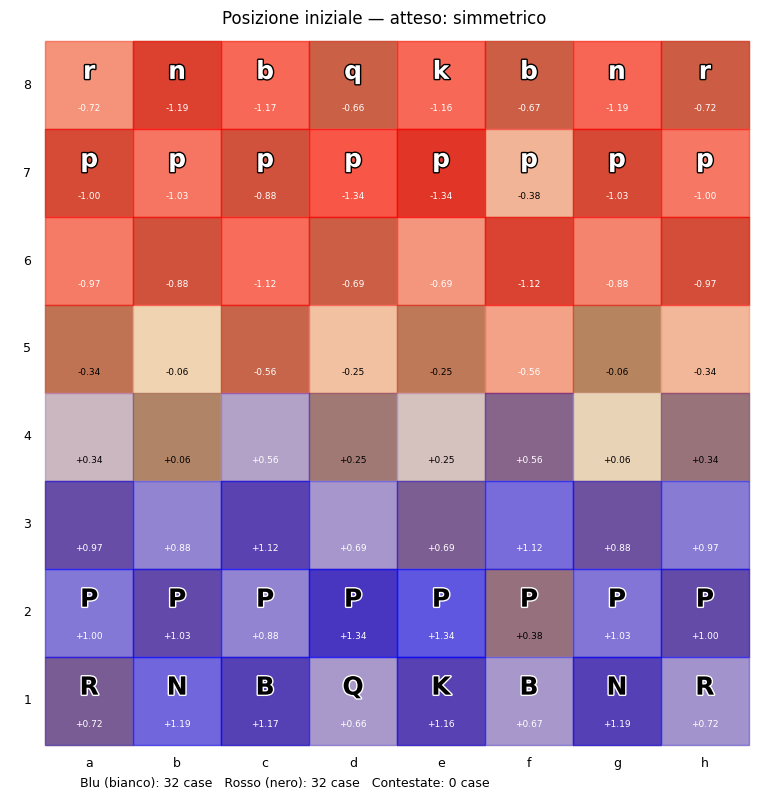

Somma totale C(x): 0.0000  (dovrebbe essere ~0)


In [3]:
fig, C = plot_annotated(
    'rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1',
    title='Posizione iniziale — atteso: simmetrico'
)
plt.show()
print(f'Somma totale C(x): {C.sum():.4f}  (dovrebbe essere ~0)')

---
## Esperimento 2: Vantaggio materiale netto
Il bianco ha una torre in più. Il campo dovrebbe essere sbilanciato verso il bianco.

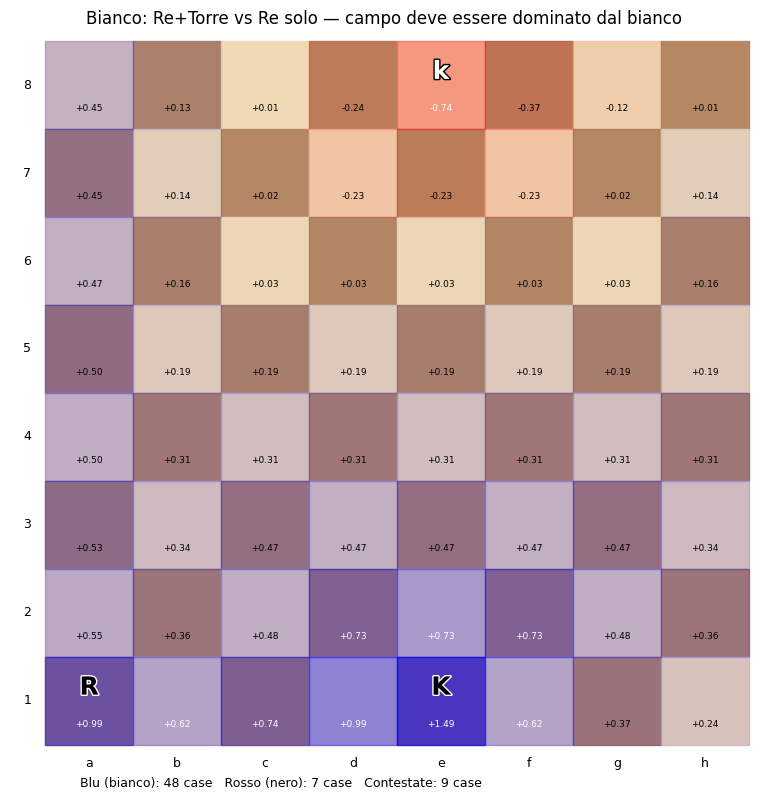

Somma C(x): 18.688  (positivo = bianco domina)


In [4]:
# Posizione semplificata: bianco ha torre extra
# Re bianchi e8, re nero e8 → usiamo posizione realistica
FEN_UP_ROOK = '4k3/8/8/8/8/8/8/R3K3 w Q - 0 1'  # bianco: Re + Torre vs Re solo

fig, C = plot_annotated(FEN_UP_ROOK,
    title='Bianco: Re+Torre vs Re solo — campo deve essere dominato dal bianco')
plt.show()
print(f'Somma C(x): {C.sum():.3f}  (positivo = bianco domina)')

---
## Esperimento 3: Forchetta del cavallo
Il cavallo bianco su c7 minaccia contemporaneamente la torre su a8 e il re su e8.
Domanda: il campo cattura la tensione di questa casa?
Atteso: c7 fortemente blu, le case a8 e e8 cambiano colore.

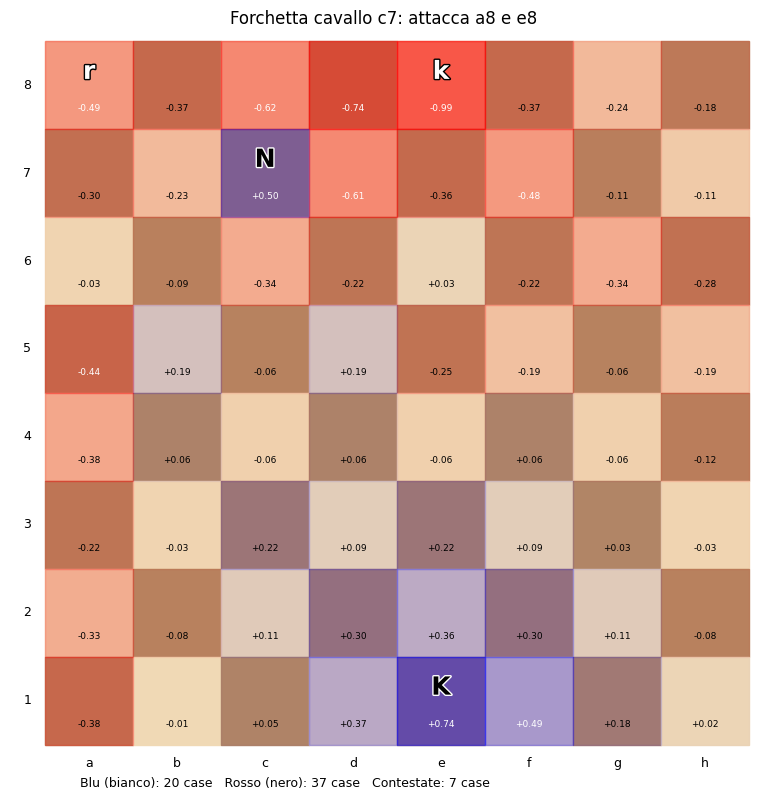

C(a8) = -0.492  (torre nera: atteso < 0 o contestato)
C(c7) = +0.500  (cavallo bianco: atteso > 0)
C(e8) = -0.992  (re nero: interessante — il campo lo vede?)


In [5]:
# Cavallo bianco in c7, attacca a8 (torre nera) e e8 (re nero)
FEN_FORK = 'r3k3/2N5/8/8/8/8/8/4K3 w - - 0 1'

fig, C = plot_annotated(FEN_FORK,
    title='Forchetta cavallo c7: attacca a8 e e8')
plt.show()

# Leggiamo i valori nelle case critiche
# a8 = row 0, col 0 | c7 = row 1, col 2 | e8 = row 0, col 4
print(f'C(a8) = {C[0,0]:+.3f}  (torre nera: atteso < 0 o contestato)')
print(f'C(c7) = {C[1,2]:+.3f}  (cavallo bianco: atteso > 0)')
print(f'C(e8) = {C[0,4]:+.3f}  (re nero: interessante — il campo lo vede?)')

---
## Esperimento 4: Confronto prima/dopo una mossa tattica
Sacrificio di qualità: il campo cambia molto o poco?

‖ΔC‖ mossa migliore (h3g4): 3.0870
‖ΔC‖ mossa debole   (a2a3):        1.3537


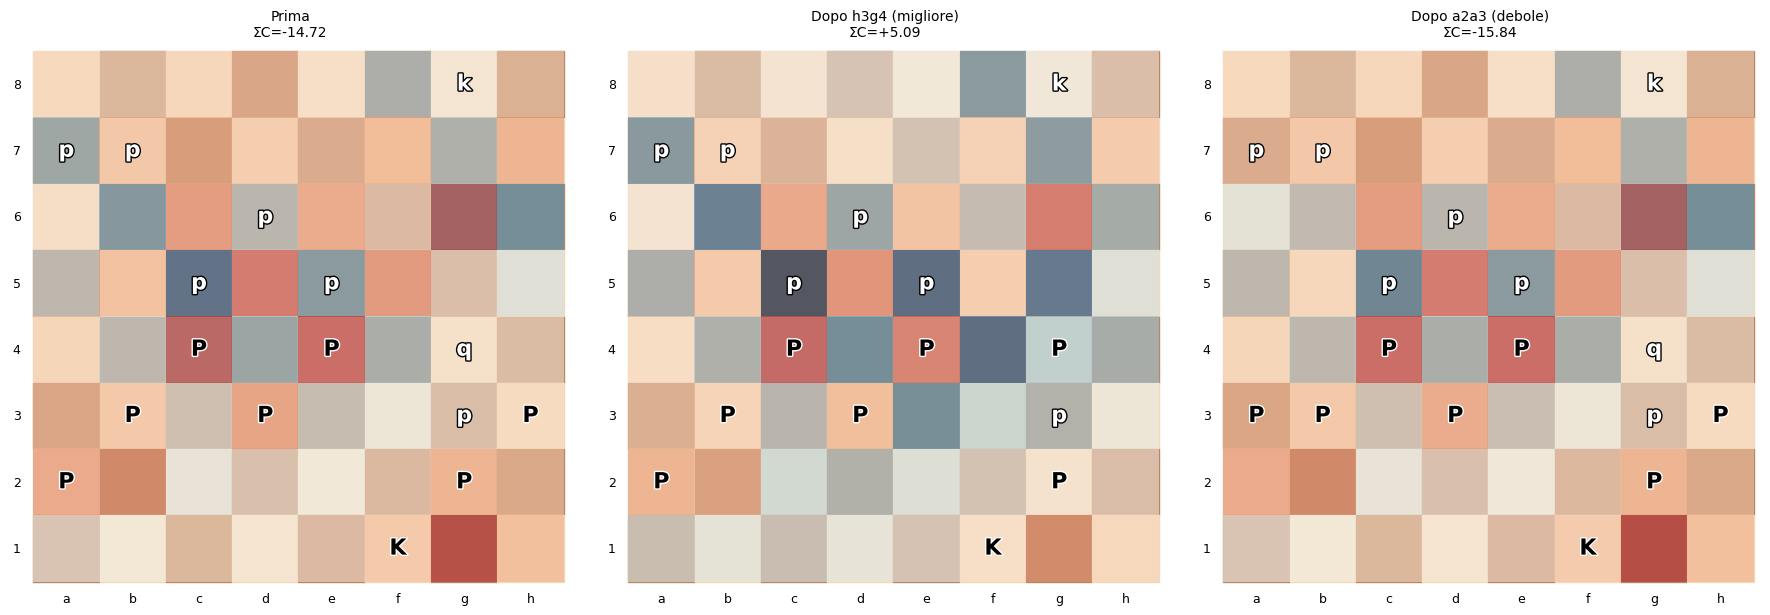

In [12]:
import chess

def apply_move(fen, move_uci):
    """Applica una mossa UCI a una FEN e restituisce la FEN risultante."""
    board = chess.Board(fen)
    board.push_uci(move_uci)
    return board.fen()

# Prendi una riga dal tuo CSV
fen_before = '6k1/pp6/3p4/2p1p3/2P1P1q1/1P1P2pP/P5P1/5K2 w - - 0 31'
best_move  = 'h3g4'  # la mossa migliore secondo Stockfish
fen_after  = apply_move(fen_before, best_move)

# Mossa alternativa debole
fen_weak   = apply_move(fen_before, 'a2a3')  # mossa casuale

delta_best = field_delta(fen_before, fen_after)
delta_weak = field_delta(fen_before, fen_weak)

print(f'‖ΔC‖ mossa migliore ({best_move}): {delta_best:.4f}')
print(f'‖ΔC‖ mossa debole   (a2a3):        {delta_weak:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, fen, title in [
    (axes[0], fen_before, 'Prima'),
    (axes[1], fen_after,  f'Dopo {best_move} (migliore)'),
    (axes[2], fen_weak,   'Dopo a2a3 (debole)'),
]:
    fields = compute_fields_from_fen(fen, alpha=0.5)
    C = fields['control'][::-1, :]
    vmax = max(abs(C).max(), 1e-6)
    ax.imshow(C, cmap='RdBu', extent=[0,8,0,8],
              vmin=-vmax, vmax=vmax, alpha=0.55, zorder=1)
    _draw_board_base(ax, fields['board'])
    ax.set_title(f'{title}\nΣC={fields["control"].sum():+.2f}', fontsize=10)
plt.tight_layout()
plt.show()

---
## Esperimento 5: Il campo predice la mossa migliore?
Idea: la casa con il massimo gradiente di C(x) (dove il campo cambia di più)
corrisponde alla casa più 'tesa' — spesso la casa della mossa migliore.

=== Analisi tensione posizionale ===
Case più tese (entrambi contendono):
  e4: tensione=2.000, C=-0.062
  g4: tensione=1.875, C=-0.125
  e5: tensione=1.688, C=-0.062
  f5: tensione=1.625, C=-0.125
  d5: tensione=1.625, C=-0.938

Case più dominate dal bianco:
  d1: C=+1.562
  f2: C=+1.500
  c2: C=+1.438
  f1: C=+1.422
  c1: C=+1.297

Case più dominate dal nero:
  f7: C=-1.469
  d8: C=-1.453
  c8: C=-1.344
  b8: C=-1.297
  e8: C=-1.266


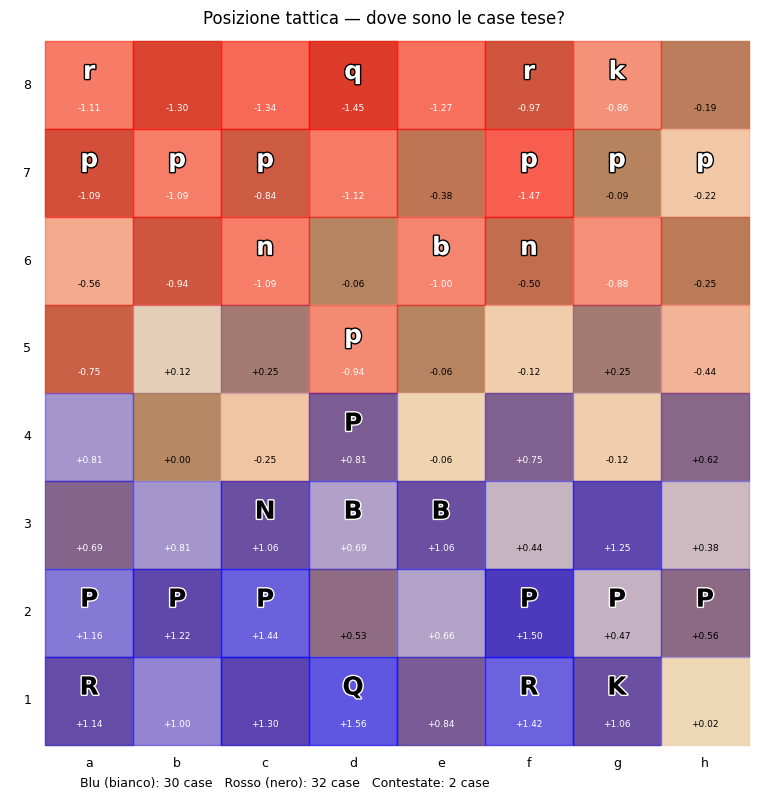

In [7]:
def top_contested_squares(fen, alpha=0.5, n=5):
    """
    Restituisce le n case più contestate (|C(x)| minimo = massima tensione)
    e le n case di massima dominanza bianca/nera.
    """
    fields = compute_fields_from_fen(fen, alpha=alpha)
    C = fields['control']

    # Case più contestate: |C(x)| piccolo ma entrambe le influenze alte
    W = fields['white']
    B = fields['black']
    tension = np.minimum(W, B)  # alto dove entrambi hanno influenza

    flat_tension = tension.flatten()
    flat_C       = C.flatten()

    top_tension_idx = np.argsort(flat_tension)[::-1][:n]
    top_white_idx   = np.argsort(flat_C)[::-1][:n]
    top_black_idx   = np.argsort(flat_C)[:n]

    def idx_to_sq(idx):
        r, c = divmod(idx, 8)
        return f"{'abcdefgh'[c]}{8-r}"

    print('Case più tese (entrambi contendono):')
    for idx in top_tension_idx:
        print(f'  {idx_to_sq(idx)}: tensione={flat_tension[idx]:.3f}, C={flat_C[idx]:+.3f}')

    print(f'\nCase più dominate dal bianco:')
    for idx in top_white_idx:
        print(f'  {idx_to_sq(idx)}: C={flat_C[idx]:+.3f}')

    print(f'\nCase più dominate dal nero:')
    for idx in top_black_idx:
        print(f'  {idx_to_sq(idx)}: C={flat_C[idx]:+.3f}')

    return C, tension

# Posizione classica: bianco ha un alfiere forte su d5, la mossa migliore
# coinvolge proprio quella casa
FEN_TACTICAL = 'r2q1rk1/ppp2ppp/2n1bn2/3p4/3P4/2NBB3/PPP2PPP/R2Q1RK1 w - - 0 1'

print('=== Analisi tensione posizionale ===')
C, tension = top_contested_squares(FEN_TACTICAL, n=5)

fig, C_out = plot_annotated(FEN_TACTICAL,
    title='Posizione tattica — dove sono le case tese?')
plt.show()

---
## Esperimento 6: Correlazione C(x) con valutazione Stockfish
Sul tuo CSV reale — il campo integrale ΣC(x) correla con la valutazione?

Correlazione:
          eval_num  C_sum  C_abs
eval_num     1.000  0.636 -0.839
C_sum        0.636  1.000 -0.373
C_abs       -0.839 -0.373  1.000


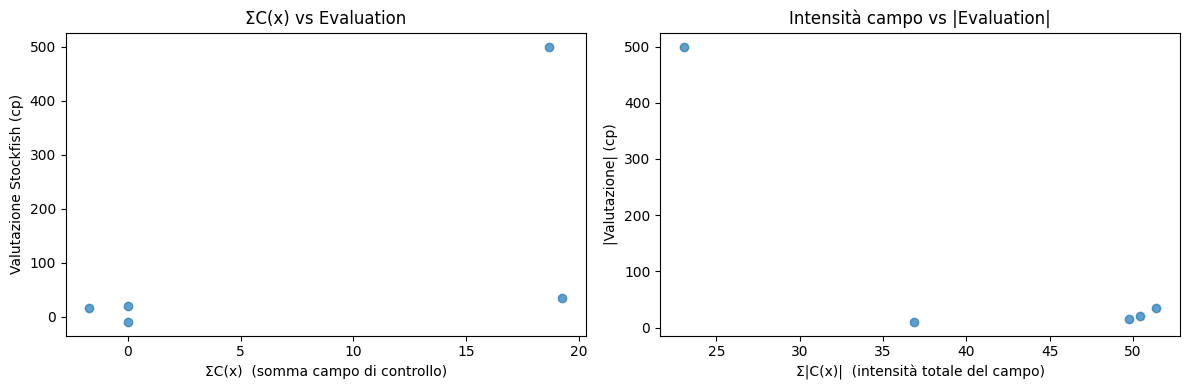

In [8]:
import pandas as pd

# ---------------------------------------------------------
# Carica il tuo CSV — modifica il path
# ---------------------------------------------------------
# df = pd.read_csv('your_dataset.csv')  # colonne: FEN, Evaluation, Move

# Per ora: simuliamo con dati fake per testare la pipeline
sample_fens = [
    ('rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1',   '+20'),
    ('rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1', '+35'),
    ('r1bqkb1r/pppp1ppp/2n2n2/4p3/2B1P3/5N2/PPPP1PPP/RNBQK2R w KQkq - 0 1', '+15'),
    ('r4rk1/ppp2ppp/2n5/3p4/3P4/2N5/PPP2PPP/R4RK1 w - - 0 1', '-10'),
    ('4k3/8/8/8/8/8/8/R3K3 w Q - 0 1', '+500'),
]
df = pd.DataFrame(sample_fens, columns=['FEN', 'Evaluation'])

def parse_eval(e):
    """Converte evaluation string in float. I matti diventano ±1000."""
    e = str(e).strip()
    if e.startswith('#'):
        moves = int(e[1:])
        return 1000.0 if moves > 0 else -1000.0
    try:
        return float(e)
    except:
        return np.nan

df['eval_num'] = df['Evaluation'].apply(parse_eval)
df['C_sum']    = df['FEN'].apply(
    lambda f: compute_fields_from_fen(f)['control'].sum()
)
df['C_abs']    = df['FEN'].apply(
    lambda f: np.abs(compute_fields_from_fen(f)['control']).sum()
)

# Clip matti per la correlazione
df_clean = df[df['eval_num'].abs() < 1000].copy()

if len(df_clean) > 2:
    corr = df_clean[['eval_num','C_sum','C_abs']].corr()
    print('Correlazione:')
    print(corr.round(3))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].scatter(df_clean['C_sum'], df_clean['eval_num'], alpha=0.7)
    axes[0].set_xlabel('ΣC(x)  (somma campo di controllo)')
    axes[0].set_ylabel('Valutazione Stockfish (cp)')
    axes[0].set_title('ΣC(x) vs Evaluation')

    axes[1].scatter(df_clean['C_abs'], df_clean['eval_num'].abs(), alpha=0.7)
    axes[1].set_xlabel('Σ|C(x)|  (intensità totale del campo)')
    axes[1].set_ylabel('|Valutazione| (cp)')
    axes[1].set_title('Intensità campo vs |Evaluation|')

    plt.tight_layout()
    plt.show()
else:
    print('Carica il CSV reale per vedere la correlazione su larga scala.')

---
## Esperimento 7: Il campo cambia di più sulla mossa migliore?
Ipotesi: la mossa migliore massimizza il cambiamento in C(x).

In [9]:
def field_delta(fen_before, fen_after, alpha=0.5):
    """Quanto cambia il campo tra due posizioni? (norma L2 della differenza)"""
    C_before = compute_fields_from_fen(fen_before, alpha=alpha)['control']
    C_after  = compute_fields_from_fen(fen_after,  alpha=alpha)['control']
    return np.linalg.norm(C_after - C_before)

# Confronta delta per mossa migliore vs mossa casuale
FEN_BASE  = 'rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1'

positions = {
    '1.e4  (mossa centrale forte)':  'rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq e3 0 1',
    '1.d4  (altro centro)':           'rnbqkbnr/pppppppp/8/8/3P4/8/PPP1PPPP/RNBQKBNR b KQkq d3 0 1',
    '1.a4  (mossa debole di fianchetto)': 'rnbqkbnr/pppppppp/8/8/P7/8/1PPPPPPP/RNBQKBNR b KQkq a3 0 1',
    '1.h4  (mossa laterale)':          'rnbqkbnr/pppppppp/8/8/7P/8/PPPPPPP1/RNBQKBNR b KQkq h3 0 1',
}

print('Delta del campo C(x) rispetto alla posizione iniziale:')
print(f'{"Mossa":<40} {"‖ΔC‖":>8}')
print('-' * 50)
for name, fen in positions.items():
    delta = field_delta(FEN_BASE, fen)
    print(f'{name:<40} {delta:>8.4f}')

print()
print('Ipotesi: mosse centrali forti → delta maggiore.')
print('Se è così, ‖ΔC‖ è un proxy di "quanto è impattante la mossa".')

Delta del campo C(x) rispetto alla posizione iniziale:
Mossa                                        ‖ΔC‖
--------------------------------------------------
1.e4  (mossa centrale forte)               2.9793
1.d4  (altro centro)                       2.7775
1.a4  (mossa debole di fianchetto)         1.6323
1.h4  (mossa laterale)                     1.6323

Ipotesi: mosse centrali forti → delta maggiore.
Se è così, ‖ΔC‖ è un proxy di "quanto è impattante la mossa".
